# PHASE 9 - Error Analysis

This notebook analyzes the saved XGBoost model, which had the best test RMSE in PHASE 8. It does not retrain the model.

Errors are summarized by hour, weekday, month, season, and working-day status to identify conditions where demand is harder to predict.

In [ ]:
# Nhập các thư viện cần thiết
from pathlib import Path  # Làm việc với đường dẫn file
import pickle  # Tải các object Python

import matplotlib.pyplot as plt  # Vẽ đồ thị
import pandas as pd  # Xử lý dữ liệu

# Hàm tìm thư mục gốc của project
def find_project_root():
    # Kiểm tra từng vị trí xem có test data và XGBoost model không
    for candidate in [Path("."), Path("..")]:
        if (candidate / "data/processed/test.csv").exists() and (candidate / "models/xgboost.pkl").exists():
            return candidate
    # Nếu không tìm thấy, báo lỗi
    raise FileNotFoundError("Test data or XGBoost model is missing. Run PHASE 3 and PHASE 6 first.")

# Tìm thư mục gốc
project_root = find_project_root()

# Định nghĩa các đường dẫn cần dùng
test_path = project_root / "data/processed/test.csv"  # File dữ liệu test
model_path = project_root / "models/xgboost.pkl"  # File model XGBoost
metrics_dir = project_root / "results/metrics"  # Thư mục lưu metrics
figures_dir = project_root / "results/figures"  # Thư mục lưu hình

# Tải dữ liệu test
test_df = pd.read_csv(test_path, parse_dates=["timestamp", "dteday"])

# Tải model XGBoost từ file pickle
with model_path.open("rb") as model_file:
    saved_model = pickle.load(model_file)  # Tải dictionary chứa model và features

# Lấy model và danh sách features
model = saved_model["model"]  # Model XGBoost
feature_columns = saved_model["feature_columns"]  # Danh sách tên features

# === DỰ ĐOÁN VÀ TÍNH SAI SỐ ===
# Dự đoán trên tập test
test_predictions = model.predict(test_df[feature_columns])

# Tạo DataFrame chứa thông tin: thời gian, giá trị thực tế, dự đoán, và sai số
error_df = test_df[["timestamp", "cnt", "hr", "weekday", "mnth", "season", "workingday"]].copy()

# Đổi tên cột "cnt" thành "actual"
error_df["actual"] = error_df.pop("cnt")

# Thêm cột dự đoán
error_df["predicted"] = test_predictions

# === TÍNH CÁC LOẠI SAI SỐ ===
# Sai số = dự đoán - thực tế (âm = dự đoán thấp hơn thực tế, dương = dự đoán cao hơn thực tế)
error_df["error"] = error_df["predicted"] - error_df["actual"]

# Sai số tuyệt đối = |sai số| (mất dấu)
error_df["absolute_error"] = error_df["error"].abs()

# Sai số bình phương (dùng để tính RMSE)
error_df["squared_error"] = error_df["error"] ** 2

# In thông báo
print(f"Loaded {len(error_df)} test predictions without retraining.")

Loaded 2582 test predictions without retraining.


In [ ]:
# === TẠO BẢNG DỊCH VỊ ===
# Bảng dịch các số thành tên dễ hiểu

# Bảng dịch ngày trong tuần (0=Thứ 2, ..., 6=Chủ nhật)
weekday_names = {0: "Monday", 1: "Tuesday", 2: "Wednesday", 3: "Thursday", 4: "Friday", 5: "Saturday", 6: "Sunday"}

# Bảng dịch mùa (1=Xuân, 2=Hè, 3=Thu, 4=Đông)
season_names = {1: "Spring", 2: "Summer", 3: "Fall", 4: "Winter"}

# Bảng dịch ngày làm việc (0=Ngày không làm việc, 1=Ngày làm việc)
workingday_names = {0: "Non-working day", 1: "Working day"}

# Áp dụng bảng dịch vào DataFrame
error_df["weekday_name"] = error_df["weekday"].map(weekday_names)  # Chuyển số thành tên ngày
error_df["season_name"] = error_df["season"].map(season_names)  # Chuyển số thành tên mùa
error_df["workingday_name"] = error_df["workingday"].map(workingday_names)  # Chuyển số thành tên trạng thái

# === HÀM TỔNG HỢP SAI SỐ ===
# Hàm nhóm dữ liệu theo một cột nào đó và tính trung bình sai số
def summarize_errors(data, group_column, label_column=None):
    # Nhóm dữ liệu theo group_column và tính các chỉ số
    summary = data.groupby(group_column, as_index=False).agg(
        observations=("actual", "size"),  # Số quan sát trong mỗi nhóm
        mean_absolute_error=("absolute_error", "mean"),  # MAE trung bình
        rmse=("squared_error", lambda values: (values.mean()) ** 0.5),  # RMSE
        mean_error=("error", "mean"),  # Sai số trung bình (có dấu)
    )
    
    # Nếu có label_column, đổi tên cột group_column
    if label_column is not None:
        summary = summary.rename(columns={group_column: label_column})
    
    # Sắp xếp theo RMSE (từ cao đến thấp - những nhóm khó dự đoán nhất)
    return summary.sort_values("rmse", ascending=False).reset_index(drop=True)

# === XÁC ĐỊNH CÁC NHÓM PHÂN TÍCH ===
# Dictionary: tên nhóm -> (cột nhóm, tên cột hiển thị)
group_definitions = {
    "hour": ("hr", None),  # Phân tích theo giờ
    "weekday": ("weekday_name", None),  # Phân tích theo ngày trong tuần
    "month": ("mnth", None),  # Phân tích theo tháng
    "season": ("season_name", None),  # Phân tích theo mùa
    "workingday": ("workingday_name", None),  # Phân tích theo trạng thái ngày làm việc
}

# === TÍNH TOÁN VÀ HIỂN THỊ SAI SỐ ===
# Dictionary để lưu kết quả phân tích từng nhóm
error_summaries = {}

# Vòng lặp: phân tích từng nhóm
for name, (group_column, label_column) in group_definitions.items():
    # Tính sai số tổng hợp cho nhóm này
    error_summaries[name] = summarize_errors(error_df, group_column, label_column)
    
    # In kết quả
    print(f"Error summary by {name}:")  # Tiêu đề
    display(error_summaries[name].round(3))  # Hiển thị bảng (làm tròn 3 chữ số)

Error summary by hour:


,hr,observations,mean_absolute_error,rmse,mean_error
0,17,108,102.052,132.529,-70.837
1,18,109,85.079,116.357,-50.150
2,8,107,84.760,113.037,-68.050
3,16,108,54.545,72.702,-30.335
4,19,109,50.474,68.187,-21.691
5,15,108,44.556,60.578,-17.242
6,13,108,45.060,59.423,-1.857
7,9,107,40.922,55.367,-14.225
8,7,107,38.578,53.077,-9.510
9,12,107,40.162,51.255,-19.420


Error summary by weekday:


,weekday_name,observations,mean_absolute_error,rmse,mean_error
0,Thursday,360,41.382,69.510,-20.762
1,Tuesday,360,43.710,68.312,-14.237
2,Friday,364,37.697,64.245,-16.727
3,Wednesday,346,36.428,60.703,-15.568
4,Saturday,384,32.094,54.005,-12.959
5,Sunday,384,31.845,48.224,-14.519
6,Monday,384,29.207,44.585,-2.668


Error summary by month:


,mnth,observations,mean_absolute_error,rmse,mean_error
0,10,708,48.089,76.252,-24.212
1,9,414,45.658,71.834,-23.217
2,11,718,31.827,49.880,-7.155
3,12,742,22.811,35.474,-5.067


Error summary by season:


,season_name,observations,mean_absolute_error,rmse,mean_error
0,Fall,222,44.929,69.573,-21.900
1,Winter,2098,37.322,60.675,-15.446
2,Spring,262,16.987,25.824,6.172


Error summary by workingday:


,workingday_name,observations,mean_absolute_error,rmse,mean_error
0,Working day,1719,38.558,64.298,-17.302
1,Non-working day,863,30.644,46.501,-6.846


## Save grouped error results

In [ ]:
# === GHÉP TẤT CẢ CÁC BÀO ERROR SUMMARY ===
# Danh sách lưu các DataFrame của mỗi nhóm
summary_frames = []

# Vòng lặp: thêm cột "group" vào mỗi bảng summary
for name, summary in error_summaries.items():
    # Copy bảng để không thay đổi bảng gốc
    export_summary = summary.copy()
    
    # Thêm cột "group" ở vị trí đầu (chỉ mục 0)
    # Cột này chỉ ra rằng bảng này là phân tích theo nhóm nào
    export_summary.insert(0, "group", name)
    
    # Thêm vào danh sách
    summary_frames.append(export_summary)

# Ghép tất cả các bảng thành một DataFrame duy nhất
all_error_summaries = pd.concat(summary_frames, ignore_index=True)

# Lưu bảng error summary vào file CSV
all_error_summaries.to_csv(metrics_dir / "xgboost_error_analysis_by_group.csv", index=False)

# Lưu tất cả dự đoán và sai số vào file CSV (toàn bộ test set)
error_df.to_csv(metrics_dir / "xgboost_test_predictions_and_errors.csv", index=False)

# === TÌM CÁC ĐIỂM LỖI LỚN NHẤT ===
# Lấy 20 hàng có absolute_error lớn nhất (những dự đoán sai nhất)
worst_rows = error_df.nlargest(20, "absolute_error")

# Hiển thị 20 lỗi lớn nhất
display(worst_rows[["timestamp", "actual", "predicted", "error", "absolute_error"]])

# Lưu 20 lỗi lớn nhất vào file CSV
worst_rows[["timestamp", "actual", "predicted", "error", "absolute_error"]].to_csv(metrics_dir / "xgboost_worst_20_errors.csv", index=False)

,timestamp,actual,predicted,error,absolute_error
431,2012-10-01 17:00:00,856,447.536774,-408.463226,408.463226
864,2012-10-19 18:00:00,233,528.335632,295.335632,295.335632
1267,2012-11-07 01:00:00,92,385.161560,293.161560,293.161560
673,2012-10-11 19:00:00,743,454.326324,-288.673676,288.673676
648,2012-10-10 18:00:00,844,566.800354,-277.199646,277.199646
862,2012-10-19 16:00:00,565,292.808228,-272.191772,272.191772
120,2012-09-18 18:00:00,281,548.257812,267.257812,267.257812
335,2012-09-27 17:00:00,905,640.028503,-264.971497,264.971497
167,2012-09-20 17:00:00,976,714.235046,-261.764954,261.764954
264,2012-09-24 18:00:00,853,592.555603,-260.444397,260.444397


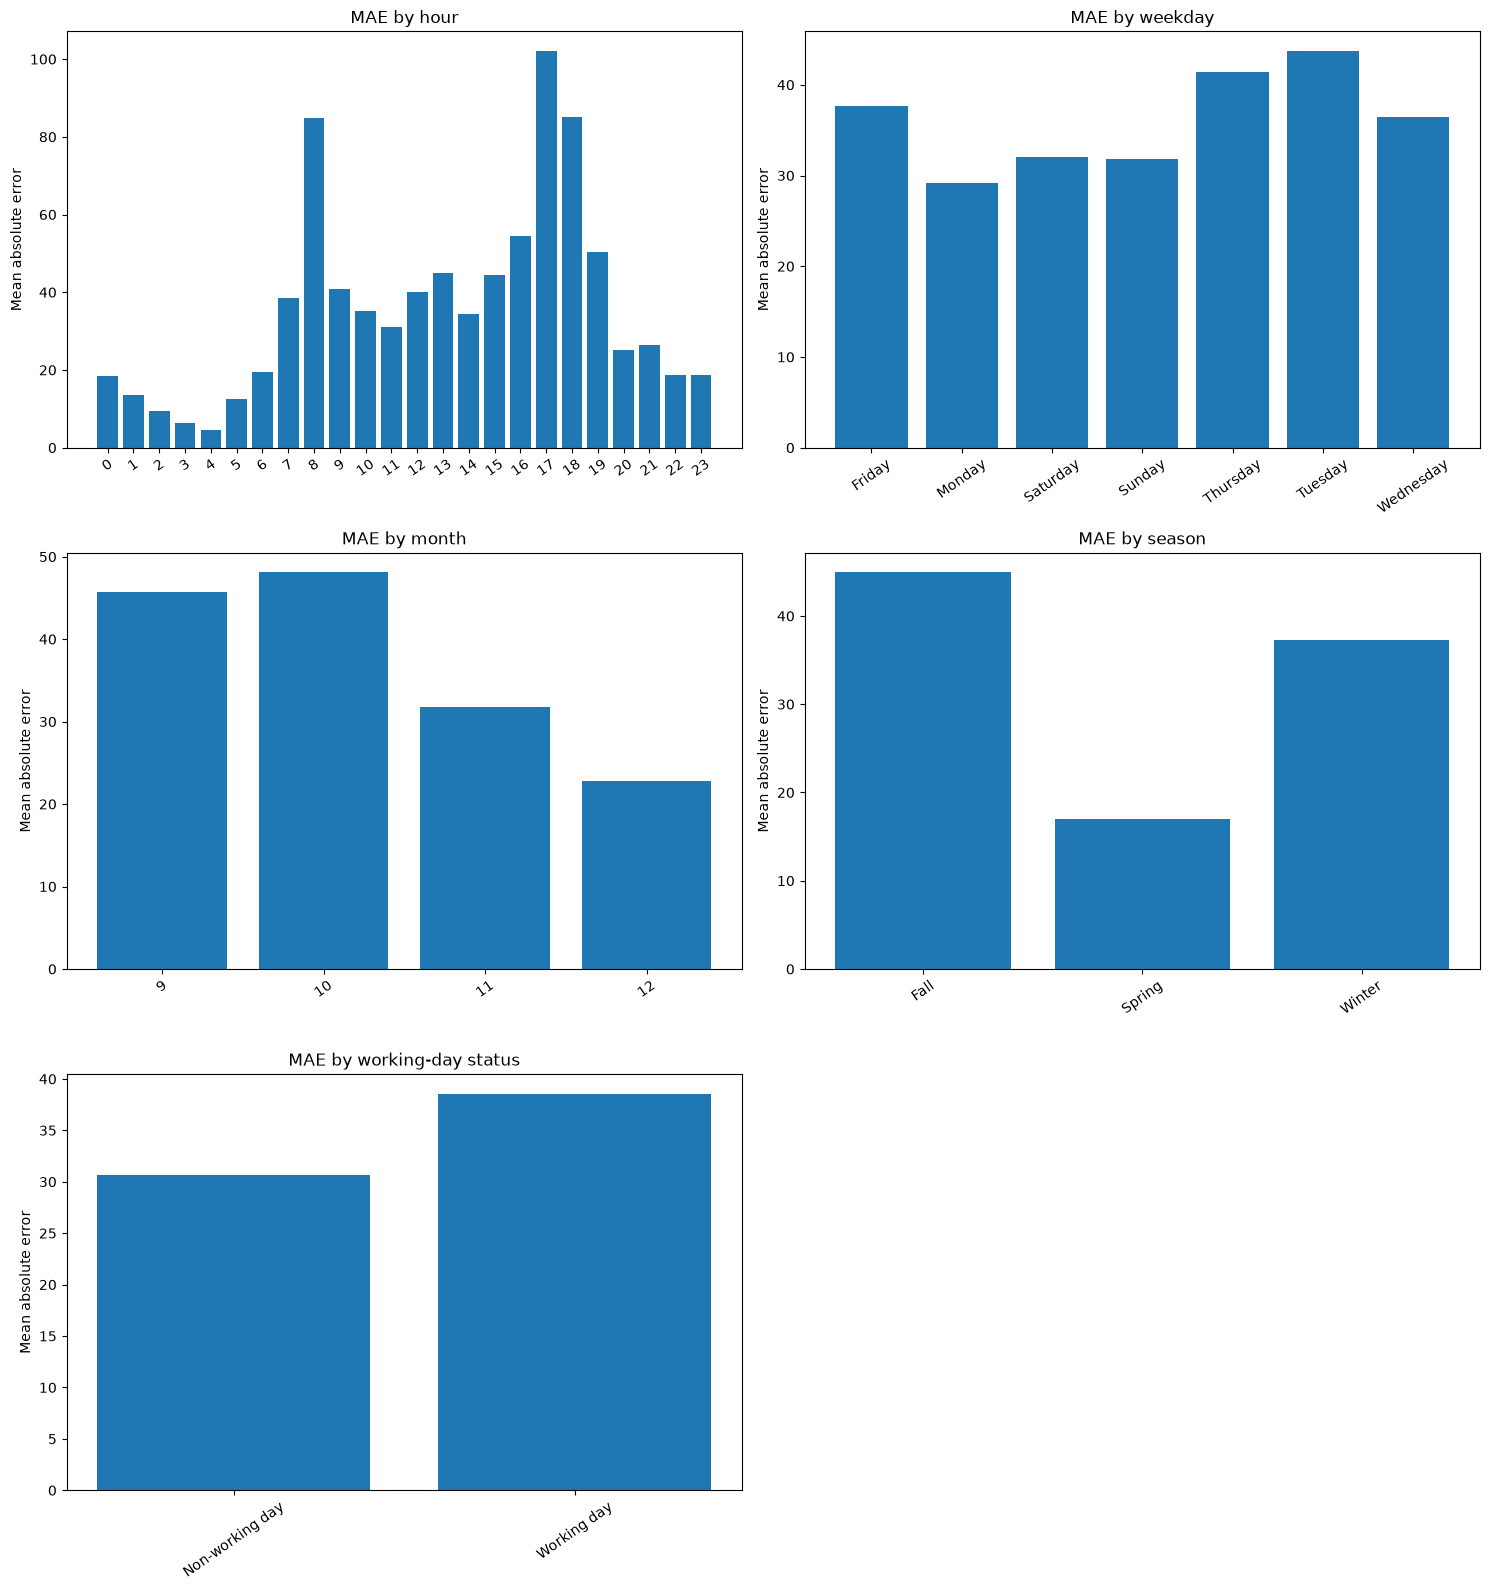

In [ ]:
# === ĐỊNH NGHĨA CÁC BIỂU ĐỒ ===
# Danh sách các biểu đồ cần vẽ
# (tên nhóm, cột để sắp xếp, tiêu đề biểu đồ)
plot_specs = [
    ("hour", "hr", "MAE by hour"),  # MAE theo giờ
    ("weekday", "weekday_name", "MAE by weekday"),  # MAE theo ngày trong tuần
    ("month", "mnth", "MAE by month"),  # MAE theo tháng
    ("season", "season_name", "MAE by season"),  # MAE theo mùa
    ("workingday", "workingday_name", "MAE by working-day status"),  # MAE theo trạng thái ngày làm việc
]

# Tạo figure với 6 subplot (3 hàng x 2 cột)
fig, axes = plt.subplots(3, 2, figsize=(15, 16))

# Vòng lặp: vẽ mỗi biểu đồ
for axis, (name, group_column, title) in zip(axes.flat, plot_specs):
    # Lấy dữ liệu của nhóm này và sắp xếp theo cột group_column
    plot_summary = error_summaries[name].sort_values(group_column)
    
    # Vẽ biểu đồ cột (bar chart)
    # X: tên nhóm (từ cột group_column)
    # Y: MAE trung bình (mean_absolute_error)
    axis.bar(plot_summary[group_column].astype(str), plot_summary["mean_absolute_error"])
    
    # Đặt tiêu đề
    axis.set_title(title)
    
    # Đặt nhãn trục Y
    axis.set_ylabel("Mean absolute error")
    
    # Quay nhãn trục X 35 độ (để dễ đọc)
    axis.tick_params(axis="x", rotation=35)

# Ẩn subplot cuối cùng (vì chỉ cần 5 biểu đồ, nhưng tạo 6 chỗ)
axes.flat[-1].axis("off")

# Điều chỉnh layout
plt.tight_layout()

# Lưu biểu đồ
plt.savefig(figures_dir / "xgboost_error_analysis_by_group.png", dpi=150)

# Hiển thị biểu đồ
plt.show()

## Phase 9 conclusion

The saved tables and charts show which time and calendar groups have the largest prediction errors. Use the highest RMSE groups as candidates for future feature improvements.